In [ ]:
# Install the torchmetrics package for storing loss, evaluation metrics, etc.
!pip install lightning-utilities

In [ ]:
# Install the torchmetrics package for storing loss, evaluation metrics,etc.
!pip install torchmetrics --no-deps
# Install the torchinfo package for showing the network information
!pip install torchinfo --no-deps
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unin

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import random_split
from torchvision.transforms import v2
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [ ]:
# Make sure to change runtime to GPU
# Check if GPU is avaiable
device = "cuda" if torch.cuda.is_available() \
else "mps" if torch.mps.is_available() \
else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ascanipek/skin-diseases")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-diseases


In [ ]:
#Augemtation for train
train_transform = v2.Compose([
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), #Adjust color
    v2.RandomHorizontalFlip(p=0.5), # Random Horizontal split
    v2.RandomResizedCrop(size=224,  scale=(0.5, 1.0)), #Random crop and resize
    v2.ToImage(), #pytorch Image format
    v2.ToDtype(torch.float32, scale=True), #convert to tensor
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #Normalize
])

In [ ]:
# data augmentation for validation and test
eval_transform = v2.Compose([
  v2.Resize((224, 224)), # resize image to 224
  v2.ToImage(), # PyTorch Image format
  v2.ToDtype(torch.float32, scale=True), # Convert to tensor
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]), # Normalize
])

In [ ]:
# Read datasets
train_data = torchvision.datasets.ImageFolder("/kaggle/input/skin-diseases/kaggle/train", transform=train_transform)
val_data = torchvision.datasets.ImageFolder("/kaggle/input/skin-diseases/kaggle/train", transform=eval_transform)
test_set = torchvision.datasets.ImageFolder("//kaggle/input/skin-diseases/kaggle/test", transform=eval_transform)

In [ ]:
#split the original train data into training (80%) and validation (20%)
#Random split (only splitting indices, datasets are independent)
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_indices, val_indices = torch.utils.data.random_split(range(len(train_data)),
[train_size,val_size])
# train_data and val_data have different transforms
train_set = torch.utils.data.Subset(train_data, train_indices)
#val_set = torch.utils.data.Subset(val_data, val_indices)
val_set = torch.utils.data.Subset(val_data, torch.utils.data.random_split(range(len(val_data)), [val_size, len(val_data)-val_size])[0])

In [ ]:
# Define the classes
classes = ["infectious skin diseases", "Eczema", "Acne", "Pigment Diseases", "Benign", "Malign"]

num_class = len(classes)
print("Number of classes:", num_class)

Number of classes: 6


In [ ]:
# Define the data loaders for the training, validation, and test sets
train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

In [ ]:
print("number of train samples:", len(train_set))
print("number of val samples:", len(val_set))
print("number of test samples:", len(test_set))

number of train samples: 24727
number of val samples: 6182
number of test samples: 3928


In [ ]:
def count_class_sample_number(dataset, classes):
# Get the labels of all the data in the training set
  labels = [dataset[i][1] for i in range(len(dataset))]
  # Count the number of data per class
  class_counts = np.bincount(labels)
  # Print the number of samples per class
  for class_label, count in enumerate(class_counts):
    print("Class", classes[class_label], "has", count, "samples.")


In [ ]:
#adjust the class weights in the loss function to penalize the model more for misclassifying minority classes
# Class frequencies in my dataset (from my training data)
class_counts = np.array([4805, 3257, 1733, 814, 8647, 5471]) # distribution of training

# Calculate the inverse frequency for each class
inverse_weights = 1.0 / class_counts

# Normalize weights (optional step, sums to 1.0 for balance)
normalized_weights = inverse_weights / np.sum(inverse_weights)

# Convert to a tensor for use with the PyTorch loss function
class_weights = torch.tensor(normalized_weights, dtype=torch.float)

print(class_weights)

tensor([0.0795, 0.1172, 0.2203, 0.4691, 0.0442, 0.0698])


In [ ]:
from transformers import AutoModelForImageClassification, AutoFeatureExtractor

In [ ]:
pip install torch torchvision

In [ ]:
from torch.optim import AdamW

In [ ]:
model3 = torchvision.models.vit_b_16(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 227MB/s]


In [ ]:
print(model3)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
model3.heads.head = nn.Linear(model3.heads.head.in_features, num_class)

In [ ]:
print(model3)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Sending to device
model3 = model3.to(device)


In [ ]:
optimizer = torch.optim.Adam(model3.parameters(), lr=0.0001)
criteria = nn.CrossEntropyLoss(weight=class_weights.to(device))

Experiment

In [ ]:
# a function for training one epoch
def train_one_epoch(model3, dataloader):
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=6).to(device)
  model3.train() # set model to train mode
  # a loop to iterate input(X) and label(Y) for all mini-batches
  for X, Y in tqdm(dataloader):
    X = X.to(device)
    Y = Y.to(device)
    optimizer.zero_grad() # reset optimizer
    preds = model3(X) # model forward
    loss = criteria(preds, Y) # calculate loss
    loss.backward() # compute gradients via backpropagation
    optimizer.step() # perform gradient descent
    preds = preds.argmax(dim=1) # obtain the final predicted class
    losses.update(loss, X.size(0)) # store loss per batch
    acc.update(preds, Y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

In [ ]:
# a function for validation one epoch
def validation_one_epoch(model3, dataloader):
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(device)
  acc = Accuracy(task='multiclass', num_classes=6).to(device)
  model3.eval() # set model to validation mode
  with torch.no_grad(): # disables gradient computation for evaluation
    # a loop to iterate input(X) and label(Y) for all mini-batches
    for X, Y in tqdm(dataloader):
      X = X.to(device)
      Y = Y.to(device)
      preds = model3(X) # model forward
      loss = criteria(preds, Y) # calculate loss
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, Y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

In [ ]:
# Prepare for storing loss and accuracy
history3 = pd.DataFrame() # store statics for each epoch
epochs = 10 # number of epochs
# a loop for epochs
for i in range(0, epochs):
  # train one epoch
  train_loss, train_acc = train_one_epoch(model3, train_dataloader)
  # validation one epoch
  val_loss, val_acc = validation_one_epoch(model3, val_dataloader)
  # store and print loss and accuracy per epoch
  statistics = pd.DataFrame({
      "epoch": [i],   "train_loss": [train_loss],
                      "train_acc": [train_acc],
                      "val_loss": [val_loss],
                      "val_acc": [val_acc]})
  history3 = pd.concat([history3, statistics], ignore_index=True)
  print(statistics.to_dict(orient="records")[0])

100%|██████████| 194/194 [01:15<00:00,  2.56it/s]


{'epoch': 0, 'train_loss': 0.9503226280212402, 'train_acc': 0.6382901072502136, 'val_loss': 0.7432000041007996, 'val_acc': 0.7220963835716248}


100%|██████████| 194/194 [01:07<00:00,  2.86it/s]


{'epoch': 1, 'train_loss': 0.7533571124076843, 'train_acc': 0.7125005125999451, 'val_loss': 0.6761787533760071, 'val_acc': 0.7442575097084045}


100%|██████████| 194/194 [01:08<00:00,  2.82it/s]


...

{'epoch': 7, 'train_loss': 0.3770407736301422, 'train_acc': 0.8516196608543396, 'val_loss': 0.360888808965683, 'val_acc': 0.8286961913108826}


100%|██████████| 194/194 [01:08<00:00,  2.83it/s]


{'epoch': 8, 'train_loss': 0.3363756537437439, 'train_acc': 0.863388180732727, 'val_loss': 0.3362742066383362, 'val_acc': 0.8536072373390198}


100%|██████████| 194/194 [01:08<00:00,  2.85it/s]

{'epoch': 9, 'train_loss': 0.3102899193763733, 'train_acc': 0.8745905160903931, 'val_loss': 0.33155012130737305, 'val_acc': 0.8537690043449402}


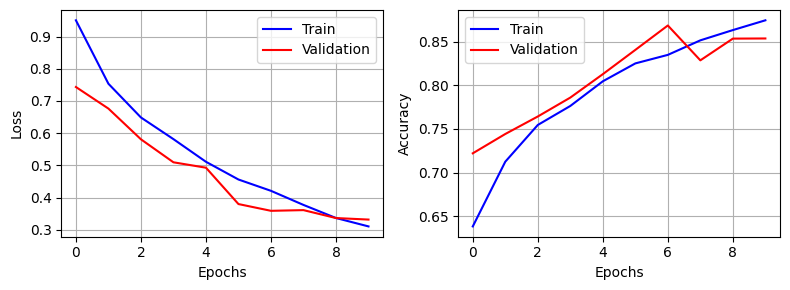

In [ ]:
# Create a figure with two subplots (side by side)
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(history3["epoch"], history3["train_loss"], label="Train", color="blue")
plt.plot(history3["epoch"], history3["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
plt.plot(history3["epoch"], history3["train_acc"], label="Train", color="blue")
plt.plot(history3["epoch"], history3["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [ ]:
# prepare for storing evaluation metrics
test_acc = Accuracy(task='multiclass', num_classes=num_class).to(device)
test_confusion_matrix=ConfusionMatrix(task="multiclass", num_classes=num_class).to(device)
test_precision = Precision(task="multiclass", num_classes=num_class, average="macro").to(device)
test_recall = Recall(task="multiclass", num_classes=num_class, average="macro").to(device)
test_f1_score = F1Score(task="multiclass", num_classes=num_class, average="macro").to(device)

model3 = model3.to(device)
model3.eval() # set model to evaluation mode
with torch.no_grad():
  for X, Y in test_dataloader:
    X = X.to(device)
    Y = Y.to(device)
    preds = model3(X) # model forward
    preds = preds.argmax(dim=1) # obtain the final predicted class
    # store loss and accuracy per batc
    test_confusion_matrix.update(preds, Y)
    test_acc.update(preds, Y)
    test_precision.update(preds, Y)
    test_recall.update(preds, Y)
    test_f1_score.update(preds, Y)
  # Print the results
  print("Confusion Matrix:\n", test_confusion_matrix.compute())
  print("Accuracy:", test_acc.compute().item())
  print("Precision:", test_precision.compute().item())
  print("Recall:", test_recall.compute().item())
  print("F1 Score:", test_f1_score.compute().item())

Confusion Matrix:
 tensor([[587,  77,  11,  37,  18,  20],
        [ 34, 431,   4,  27,   2,  12],
        [  9,   7, 292,   9,   3,   2],
        [  6,   6,   3, 116,   0,   5],
        [ 41,  15,   9,  18, 998, 280],
        [ 16,  12,   2,  16,  43, 760]], device='cuda:0')
Accuracy: 0.8105906248092651
Precision: 0.784283459186554
Recall: 0.8359988331794739
F1 Score: 0.7990474104881287


In [ ]:
from torchvision.transforms.functional import to_pil_image
import os
from PIL import Image

# Prepare storage for qualitative analysis
correct_samples = []
incorrect_samples = []

# Make sure the model is still in eval mode
model3.eval()

# Loop through test data again, this time saving image predictions
with torch.no_grad():
  for X, Y in test_dataloader:
    X, Y = X.to(device), Y.to(device)
    preds = model3(X).argmax(dim=1)

    for i in range(len(X)):
      img_tensor = X[i].cpu()
      pred_label = preds[i].item()
      true_label = Y[i].item()

      sample = {
          "image": img_tensor,
          "true_label": classes[true_label],
          "pred_label": classes[pred_label]
      }

      if pred_label == true_label:
          correct_samples.append(sample)
      else:
          incorrect_samples.append(sample)


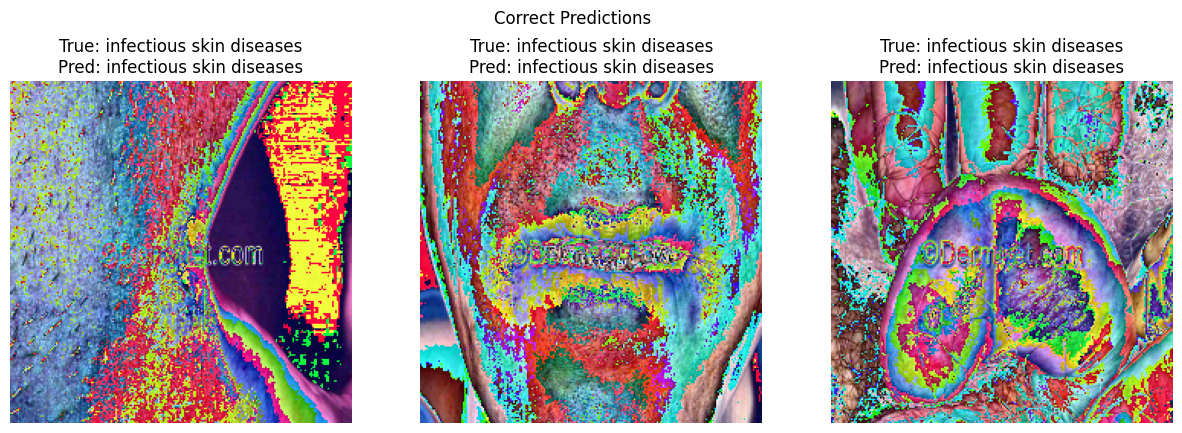

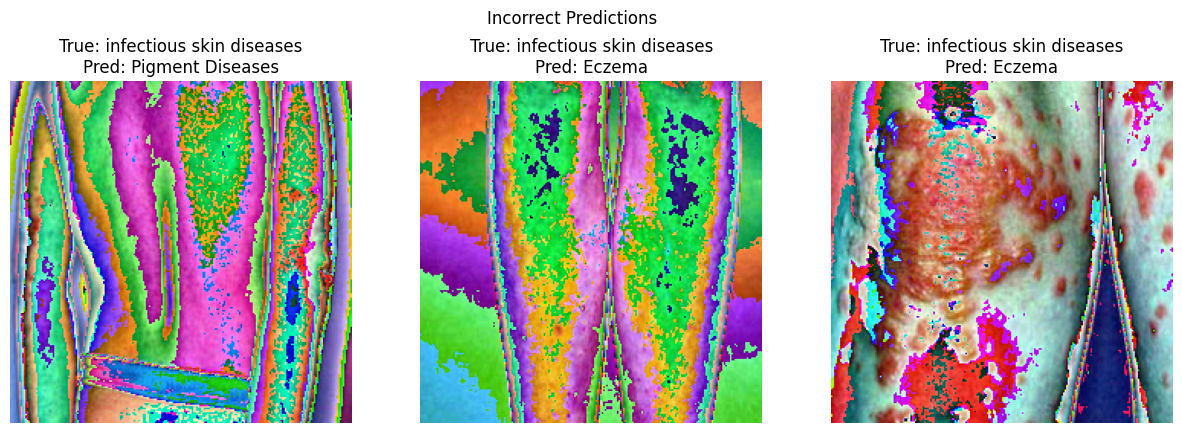

In [ ]:
def show_predictions(samples, title, n=3):
    plt.figure(figsize=(15, 5))
    for i in range(min(n, len(samples))):
        plt.subplot(1, n, i + 1)
        plt.imshow(to_pil_image(samples[i]["image"]))
        plt.title(f"True: {samples[i]['true_label']}\nPred: {samples[i]['pred_label']}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

# Show 3 correct and 3 incorrect predictions
show_predictions(correct_samples, "Correct Predictions", n=3)
show_predictions(incorrect_samples, "Incorrect Predictions", n=3)


In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

def plot_qualitative_grid(correct_samples, incorrect_samples, save_path="qualitative_grid.png"):
    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    fig.suptitle("Top: Correct Predictions | Bottom: Incorrect Predictions", fontsize=14)

    # Top row: correct predictions
    for i in range(min(3, len(correct_samples))):
        axs[0, i].imshow(to_pil_image(correct_samples[i]["image"]))
        axs[0, i].set_title(f"True: {correct_samples[i]['true_label']}\nPred: {correct_samples[i]['pred_label']}")
        axs[0, i].axis("off")

    # Bottom row: incorrect predictions
    for i in range(min(3, len(incorrect_samples))):
        axs[1, i].imshow(to_pil_image(incorrect_samples[i]["image"]))
        axs[1, i].set_title(f"True: {incorrect_samples[i]['true_label']}\nPred: {incorrect_samples[i]['pred_label']}")
        axs[1, i].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for title
    plt.savefig(save_path)
    plt.show()


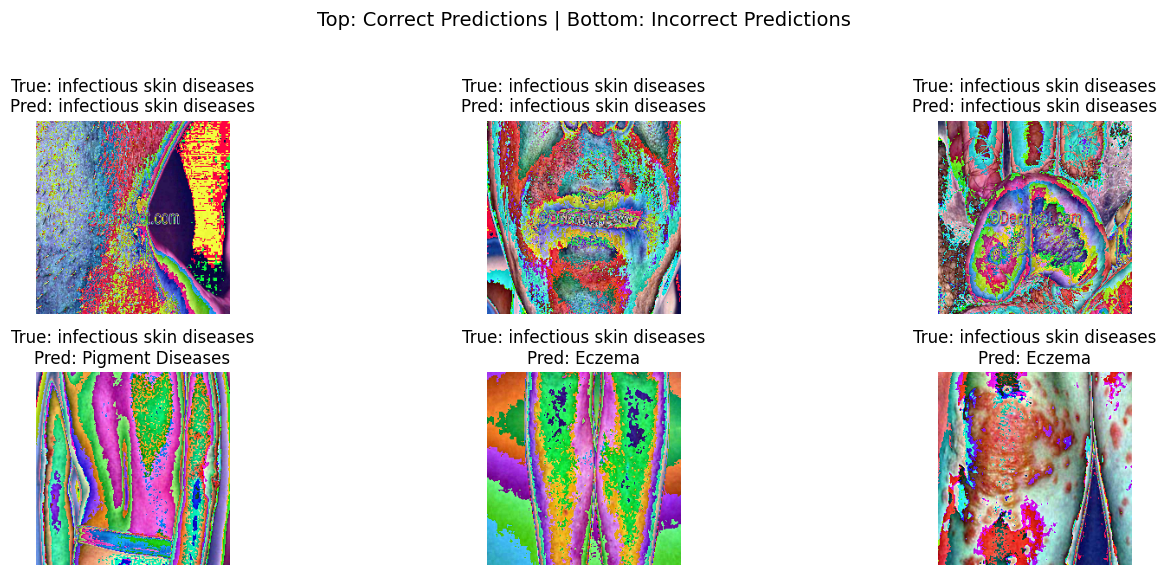

In [ ]:
plot_qualitative_grid(correct_samples, incorrect_samples)


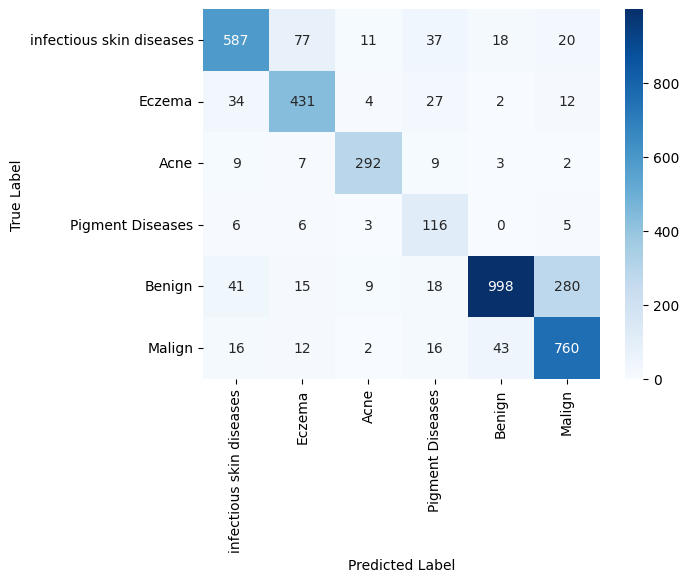

In [ ]:
# Create a heatmap for better confusion matrix visualization
sns.heatmap(test_confusion_matrix.compute().cpu(), annot=True, fmt="d",
            cmap="Blues", xticklabels=classes, yticklabels=classes)
# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()